Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [2]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_7616\2641705729.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_7616\2641705729.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_7616\2641705729.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)


Fonction d'attribution du traitement

In [3]:
def traitement(df,seuil):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 1998].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * seuil

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] > df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

Definition du modele

In [4]:
def DID (df, election, annee_deb, parti,seuil) :
    # 0. Definition du traitement
    df = traitement(df,seuil)

    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [annee_deb, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=[f'vote_{parti}_{election}', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres[f'vote_{parti}_{election}'] = df_pres[f'vote_{parti}_{election}'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('float64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome=f'vote_{parti}_{election}',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=5,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002351 0.000626 -0.003578 -0.001124 34094.0     6654.0 34094.0       6654.0
            Effect_2 -0.006359 0.000830 -0.007986 -0.004733 26007.0     6098.0 26007.0       6098.0
            Effect_3 -0.008313 0.001092 -0.010453 -0.006172 19430.0     5559.0 19430.0       5559.0
            Effect_4 -0.012187 0.001443 -0.015015 -0.009360 13392.0     4745.0 13392.0       4745.0
            Effect_5 -0.014577 0.001840 -0.018183 -0.010972  7236.0     3254.0  7236.0       3254.0
Average_Total_Effect -0.007826 0.000880 -0.009551 -0.006101 53761.0    26310.0 53761.0      26310.0
           Placebo_1  0.001390 0.000891 -0.000357  0.003136 23251.0     3352.0 23251.0       3352.0
           Placebo_2  0.000790 0.001583 -0.002311  0.003892  9956.0     1314.0  9956.0       1314.0
Test of joint nullity of the effec

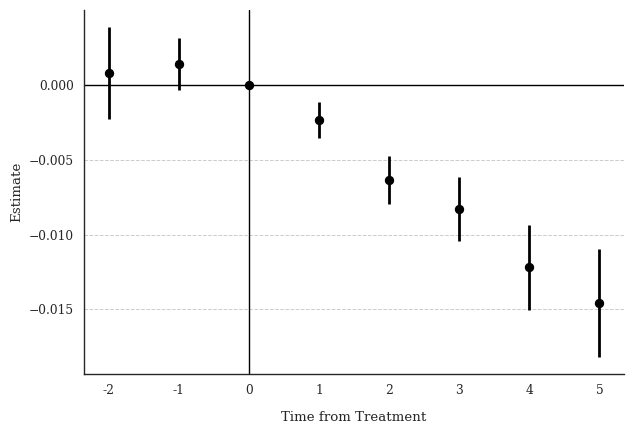

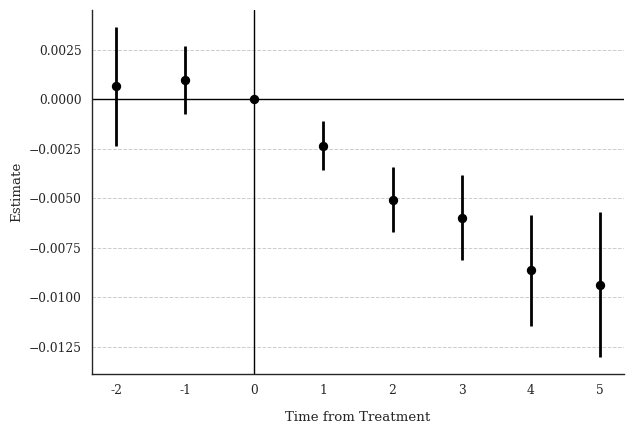

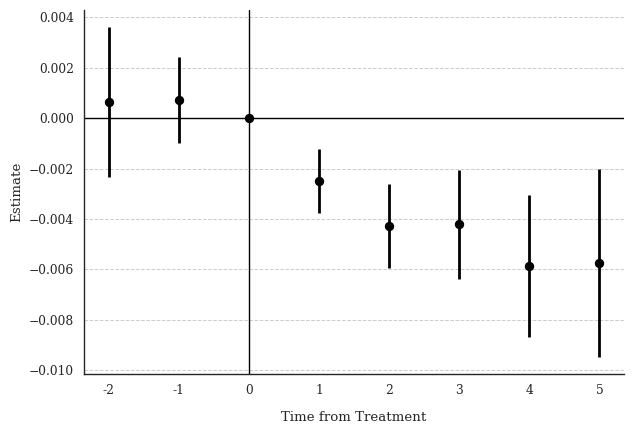

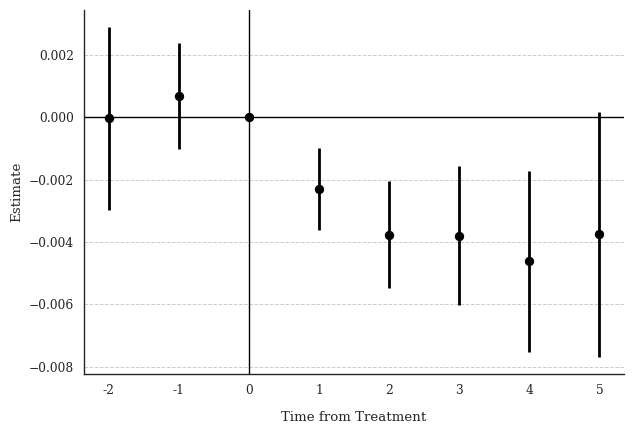

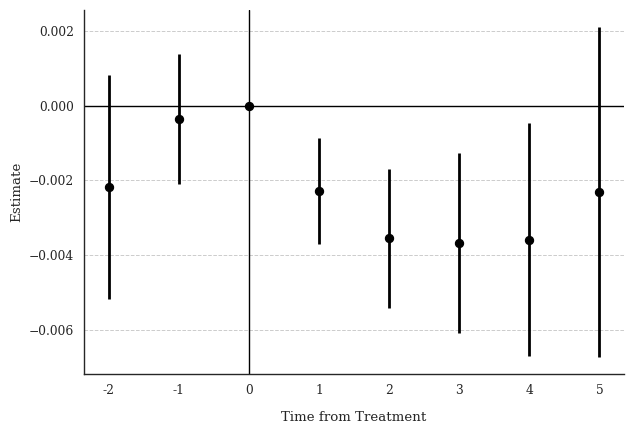

In [5]:
for seuil in [1.1,1.2,1.3,1.4,1.5] :
    DID(df_rnp, 'pres', 1995, 'RN', seuil)

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002433 0.000690 -0.003786 -0.001080 33664.0     6196.0 33664.0       6196.0
            Effect_2 -0.003080 0.000897 -0.004838 -0.001322 25576.0     5641.0 25576.0       5641.0
            Effect_3 -0.004825 0.001144 -0.007067 -0.002582 18995.0     5101.0 18995.0       5101.0
            Effect_4 -0.010210 0.001502 -0.013154 -0.007266 12953.0     4286.0 12953.0       4286.0
            Effect_5 -0.014364 0.002191 -0.018658 -0.010070  6792.0     2797.0  6792.0       2797.0
Average_Total_Effect -0.005870 0.000898 -0.007631 -0.004109 51500.0    24021.0 51500.0      24021.0
           Placebo_1  0.000314 0.000914 -0.001477  0.002105 23281.0     3356.0 23281.0       3356.0
           Placebo_2 -0.003798 0.001542 -0.006820 -0.000776  9980.0     1318.0  9980.0       1318.0
Test of joint nullity of the effec

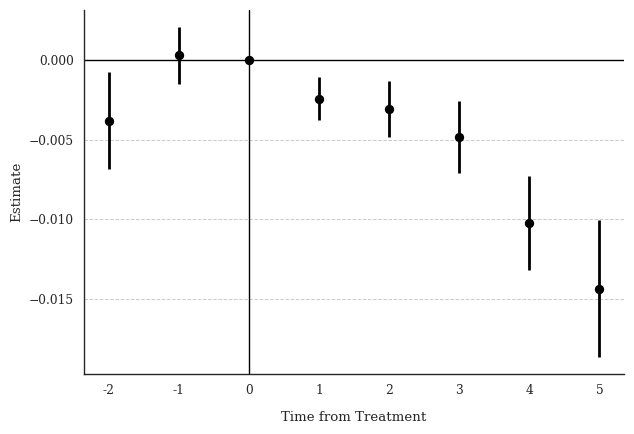

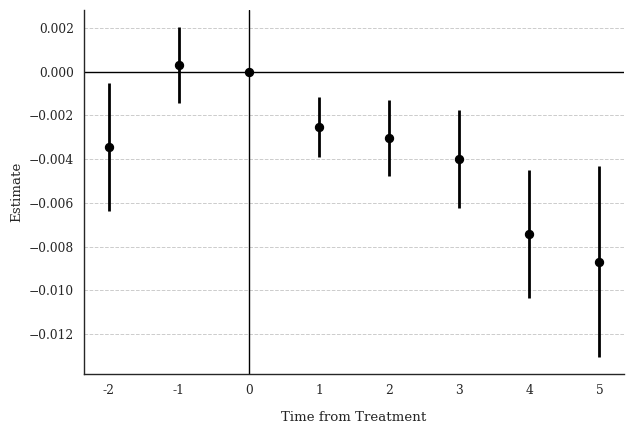

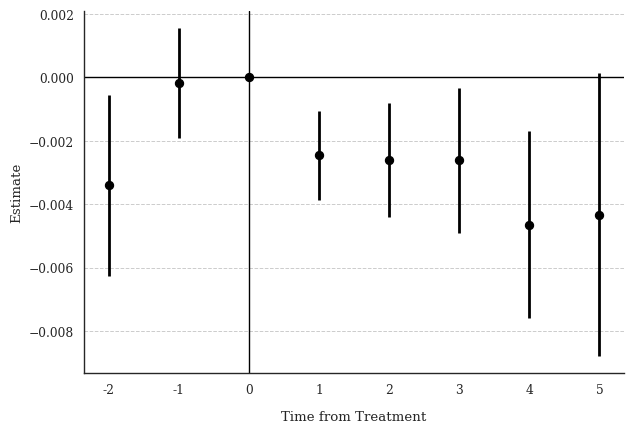

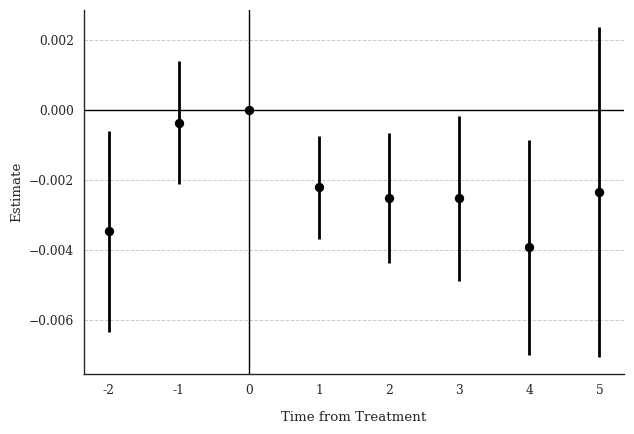

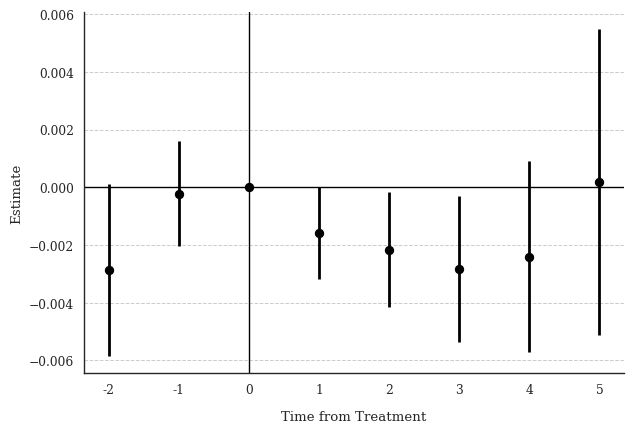

In [6]:
for seuil in [1.1,1.2,1.3,1.4,1.5] :
    DID(df_rnp, 'leg', 1997, 'RN', seuil)

### RP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000264 0.000605 -0.001450  0.000921 31676.0     6418.0 31676.0       6418.0
            Effect_2 -0.001781 0.000821 -0.003390 -0.000173 24230.0     5880.0 24230.0       5880.0
            Effect_3 -0.003797 0.001052 -0.005859 -0.001736 18121.0     5345.0 18121.0       5345.0
            Effect_4 -0.006935 0.001407 -0.009693 -0.004178 12548.0     4589.0 12548.0       4589.0
            Effect_5 -0.007545 0.001790 -0.011053 -0.004038  6941.0     3248.0  6941.0       3248.0
Average_Total_Effect -0.003485 0.000878 -0.005207 -0.001763 50744.0    25480.0 50744.0      25480.0
           Placebo_1  0.000752 0.000847 -0.000908  0.002411 21495.0     3151.0 21495.0       3151.0
           Placebo_2  0.002112 0.001653 -0.001128  0.005351  9234.0     1276.0  9234.0       1276.0
Test of joint nullity of the effec

KeyboardInterrupt: 

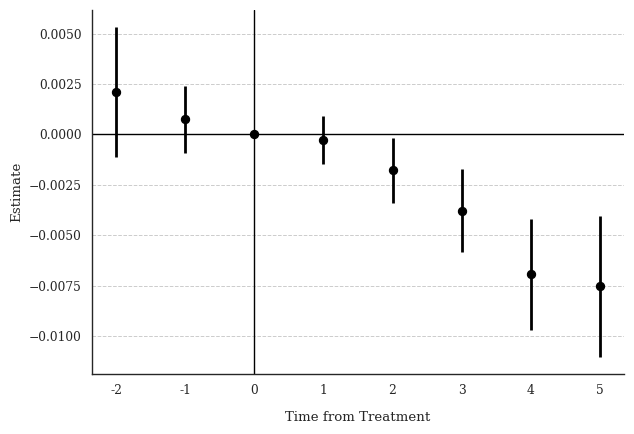

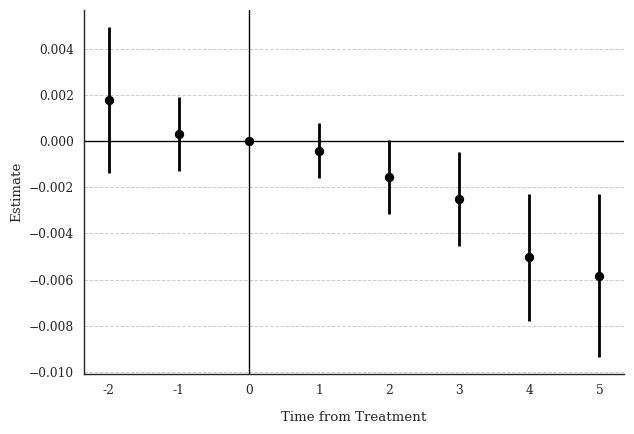

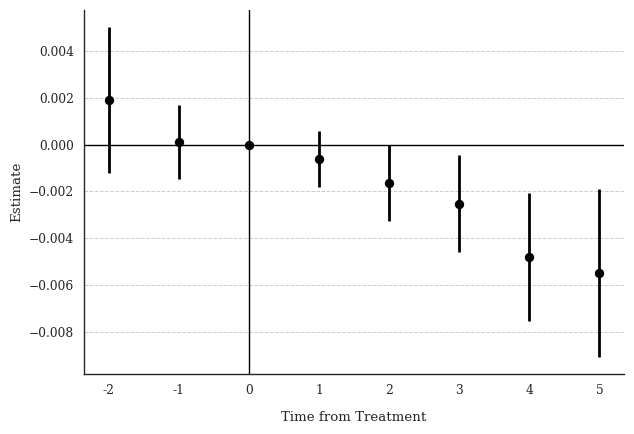

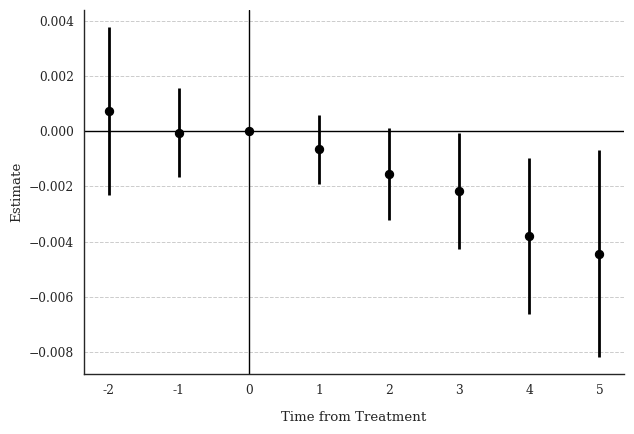

In [8]:
for seuil in [1.1,1.2,1.3,1.4,1.5] :
    DID(df_rp, 'pres', 1995, 'RN', seuil)

In [ ]:
for seuil in [1.1,1.2,1.3,1.4,1.5] :
    DID(df_rp, 'leg', 1997, 'RN', seuil)

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000482 0.000807 -0.001100 0.002064  8749.0     2141.0  8749.0       2141.0
            Effect_2  0.000842 0.001271 -0.001649 0.003332  6818.0     1993.0  6818.0       1993.0
            Effect_3 -0.000427 0.001646 -0.003653 0.002799  5238.0     1870.0  5238.0       1870.0
            Effect_4 -0.002852 0.002465 -0.007684 0.001979  3782.0     1668.0  3782.0       1668.0
            Effect_5 -0.004256 0.003178 -0.010484 0.001973  2321.0     1338.0  2321.0       1338.0
Average_Total_Effect -0.000948 0.001549 -0.003984 0.002089 15620.0     9010.0 15620.0       9010.0
           Placebo_1  0.003987 0.001199  0.001636 0.006338  5624.0      801.0  5624.0        801.0
           Placebo_2  0.010656 0.002408  0.005936 0.015376  2439.0      325.0  2439.0        325.0
Test of joint nullity of the effects: p-val

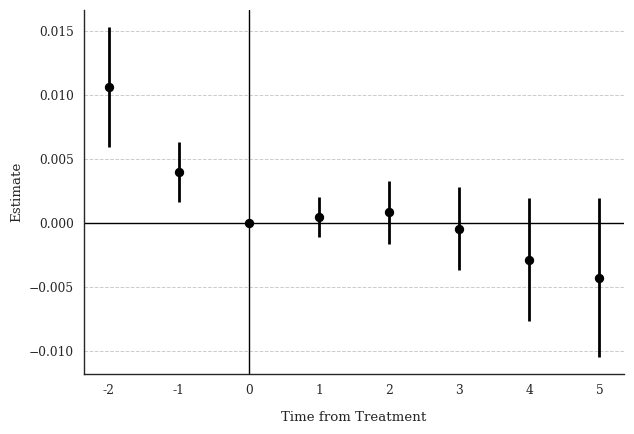

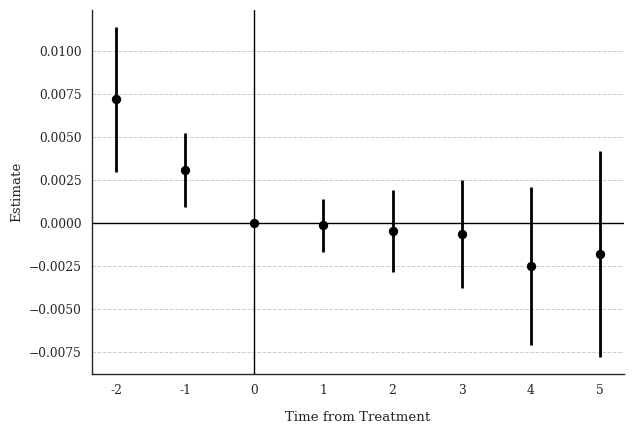

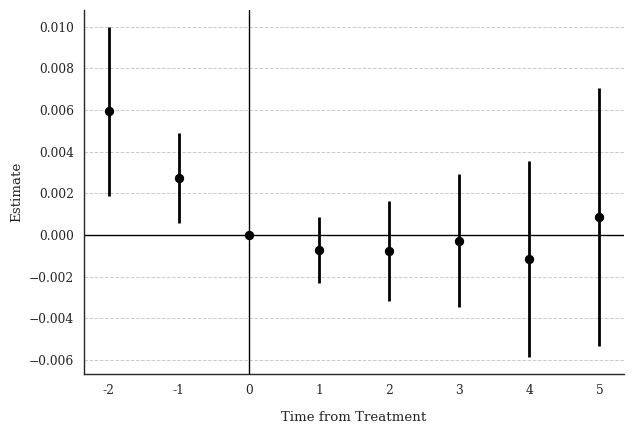

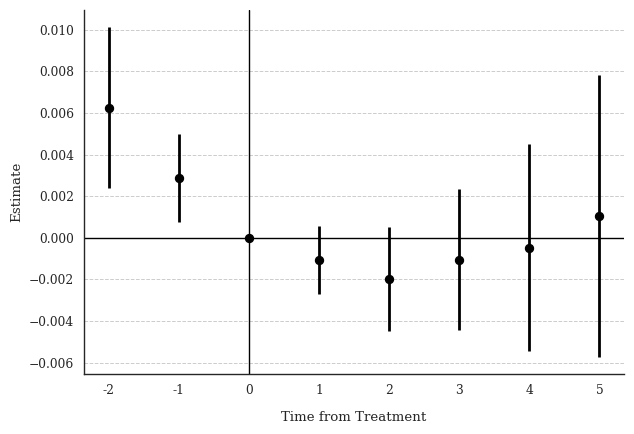

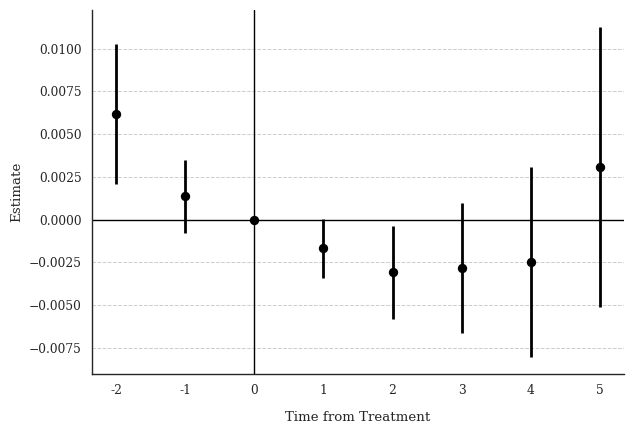

In [9]:
for seuil in [1.1,1.2,1.3,1.4,1.5] :
    DID(df_ui, 'pres', 1995, 'RN', seuil)

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000009 0.001057 -0.002062 0.002080  8521.0     1913.0  8521.0       1913.0
            Effect_2 -0.000715 0.001536 -0.003726 0.002297  6590.0     1765.0  6590.0       1765.0
            Effect_3 -0.000528 0.001912 -0.004275 0.003219  5010.0     1642.0  5010.0       1642.0
            Effect_4 -0.004608 0.002773 -0.010042 0.000827  3554.0     1440.0  3554.0       1440.0
            Effect_5 -0.006654 0.003837 -0.014174 0.000866  2093.0     1110.0  2093.0       1110.0
Average_Total_Effect -0.002050 0.001716 -0.005413 0.001313 14480.0     7870.0 14480.0       7870.0
           Placebo_1  0.003800 0.001455  0.000947 0.006652  5624.0      801.0  5624.0        801.0
           Placebo_2  0.003854 0.002580 -0.001203 0.008912  2439.0      325.0  2439.0        325.0
Test of joint nullity of the effects: p-val

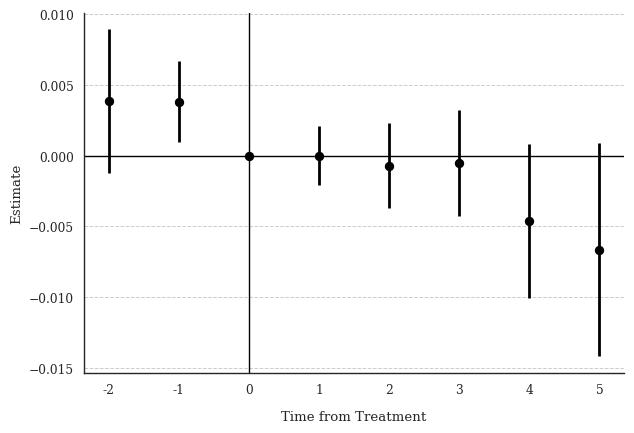

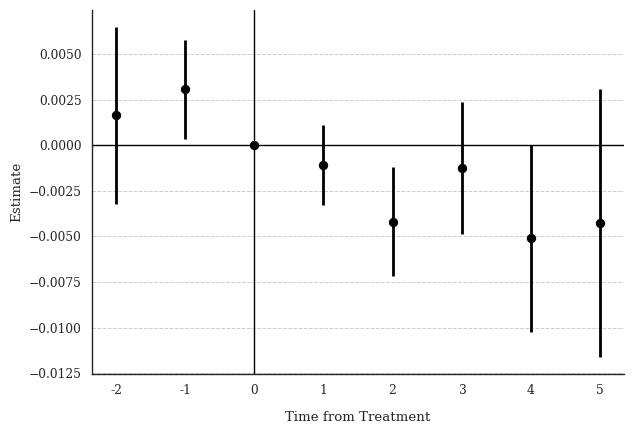

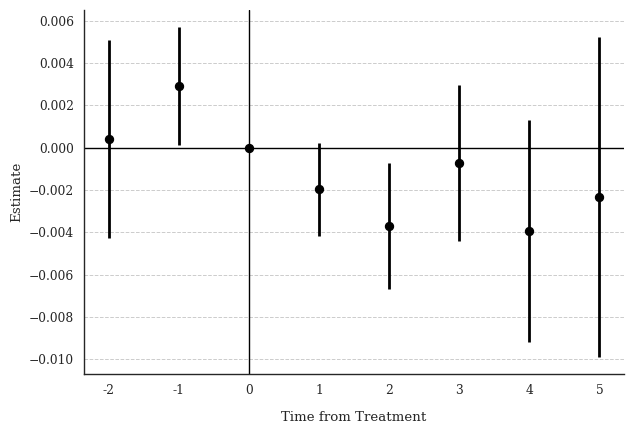

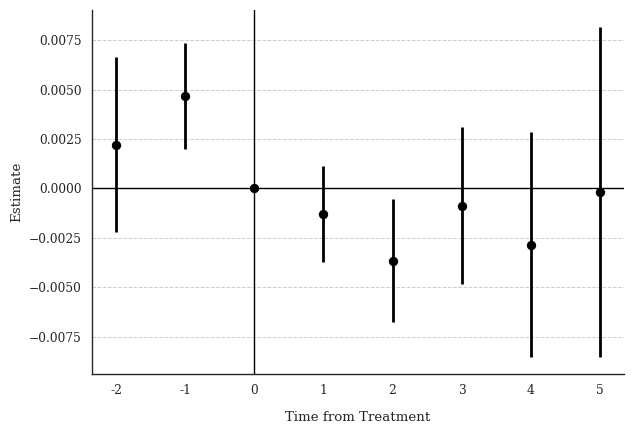

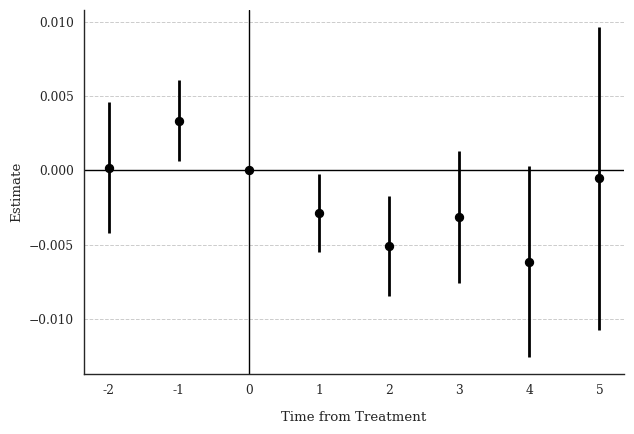

In [10]:
for seuil in [1.1,1.2,1.3,1.4,1.5] :
    DID(df_ui, 'leg', 1997, 'RN', seuil)

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI      N  Switchers    N.w  Switchers.w
            Effect_1 -0.000112 0.001371 -0.002799 0.002574 2287.0      432.0 2287.0        432.0
            Effect_2 -0.001880 0.002366 -0.006517 0.002756 1715.0      334.0 1715.0        334.0
            Effect_3  0.004413 0.003192 -0.001844 0.010670 1229.0      272.0 1229.0        272.0
            Effect_4  0.005986 0.004807 -0.003436 0.015407  805.0      241.0  805.0        241.0
            Effect_5  0.004650 0.006599 -0.008284 0.017584  425.0      192.0  425.0        192.0
Average_Total_Effect  0.001944 0.002794 -0.003533 0.007421 3326.0     1471.0 3326.0       1471.0
           Placebo_1  0.003513 0.001666  0.000247 0.006779 1621.0      240.0 1621.0        240.0
           Placebo_2  0.011936 0.003324  0.005422 0.018450  657.0       93.0  657.0         93.0
Test of joint nullity of the effects: p-value = 0.025974
Test

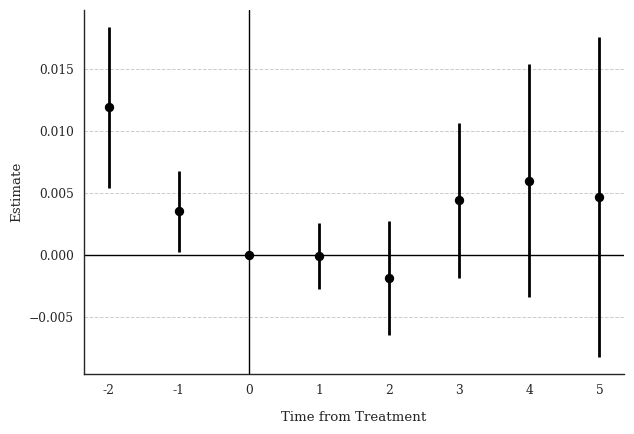

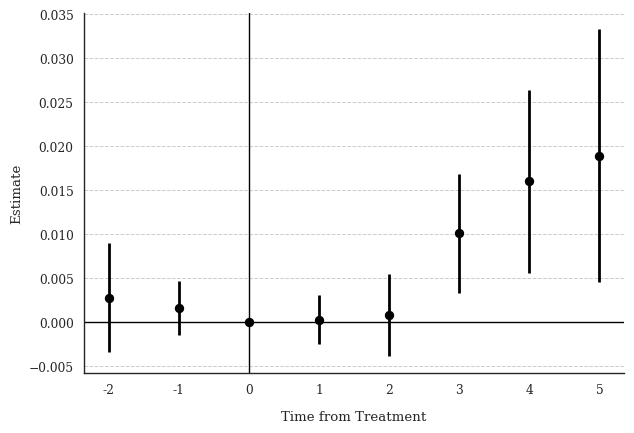

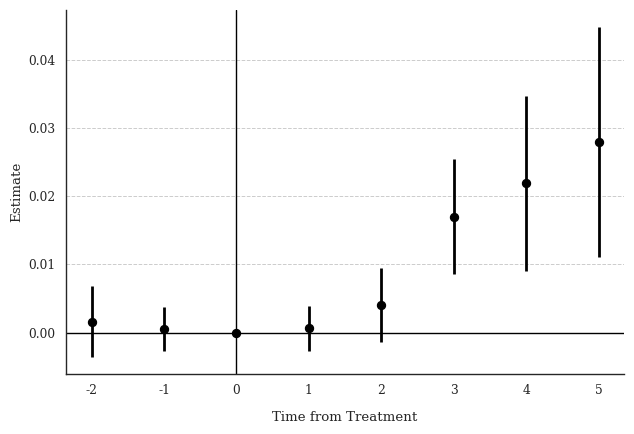

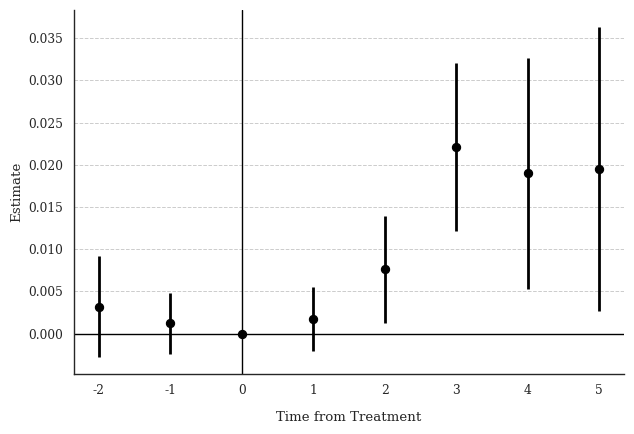

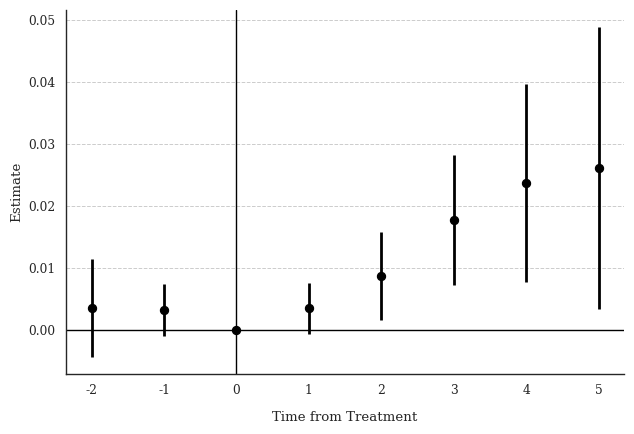

In [12]:
for seuil in [1.1,1.2,1.3,1.4,1.5] :
    DID(df_ud, 'pres', 1995, 'RN', seuil)

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI      N  Switchers    N.w  Switchers.w
            Effect_1 -0.000858 0.001883 -0.004548 0.002832 2250.0      395.0 2250.0        395.0
            Effect_2 -0.000987 0.002998 -0.006863 0.004890 1678.0      297.0 1678.0        297.0
            Effect_3  0.008314 0.003840  0.000787 0.015840 1192.0      235.0 1192.0        235.0
            Effect_4  0.008238 0.005837 -0.003202 0.019678  768.0      204.0  768.0        204.0
            Effect_5  0.015812 0.008441 -0.000733 0.032356  388.0      155.0  388.0        155.0
Average_Total_Effect  0.004240 0.003311 -0.002250 0.010730 3141.0     1286.0 3141.0       1286.0
           Placebo_1  0.000825 0.002364 -0.003809 0.005459 1621.0      240.0 1621.0        240.0
           Placebo_2  0.004729 0.004000 -0.003112 0.012569  657.0       93.0  657.0         93.0
Test of joint nullity of the effects: p-value = 0.017212
Test

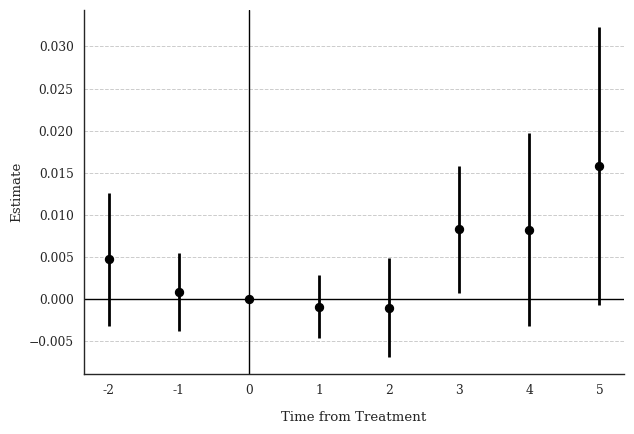

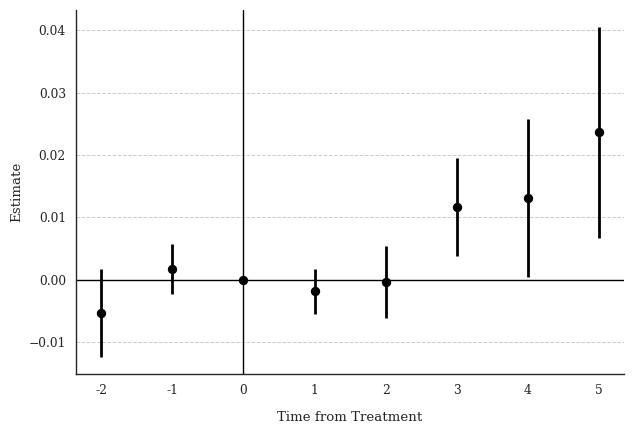

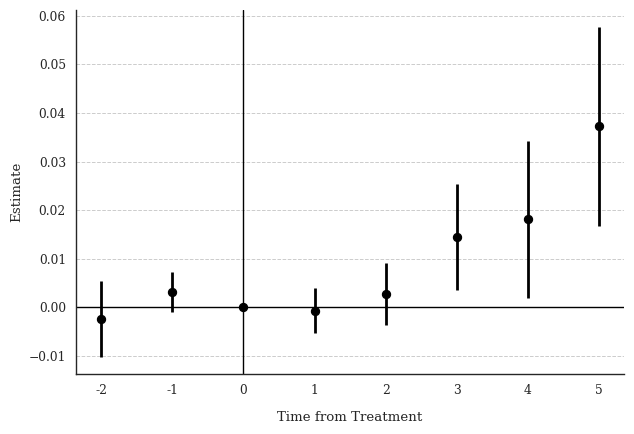

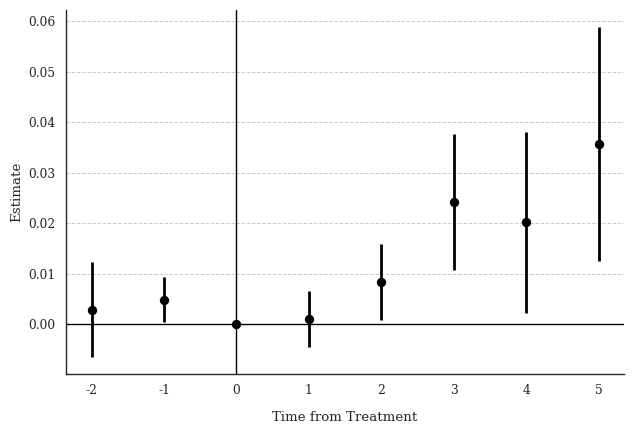

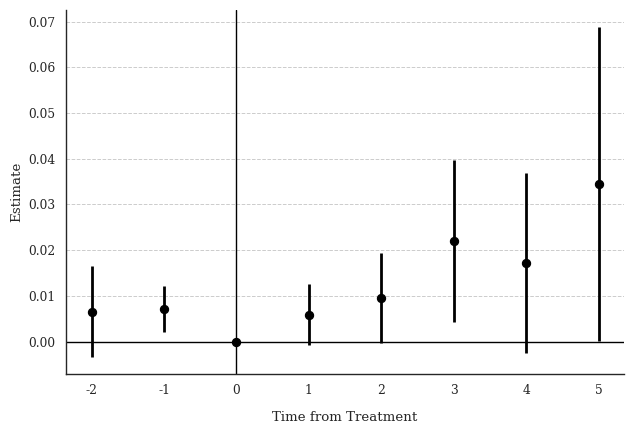

In [13]:
for seuil in [1.1,1.2,1.3,1.4,1.5] :
    DID(df_ud, 'leg', 1997, 'RN', seuil)

In [ ]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = -0.005310 
se_placebo =  0.001607 

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : -3.304
P-value du Placebo : 0.001
